# IGT Reservoir with Downscaling

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from modules.IGT_Simulation import create_pulse_train, generate_single_out_current
from modules.load_MNIST import get_images_batch
from modules.One_Node_Isometric_Reservoir import downscale_treatment
from modules.IGT_Isometric_Reservoir_Simulation import run_reservoir
import time

np.set_printoptions(threshold=np.inf)
rng = np.random.default_rng()

In [2]:
THRESHOLD_VOLTAGE = 0
SCALE_VOLTAGE = 11
VOLTAGE = 2.5
CURVATURE = 1

IMAGE_THRESHOLD = 1

# TIME_RESOLUTION = 0.2
# BETA = 0.56
# TAU = 2.6 #ms
# K = 700 #nA

TIME_RESOLUTION = 0.2
K = 400
BETA = 0.65
TAU = 3.00

NEURON_COUNT = 200

TRAIN_BATCH_SIZE = 60000
TEST_BATCH_SIZE = 10000
FLUSH_TIME=56

MAX_ITERATION = 400
LEARNING_RATE = 2

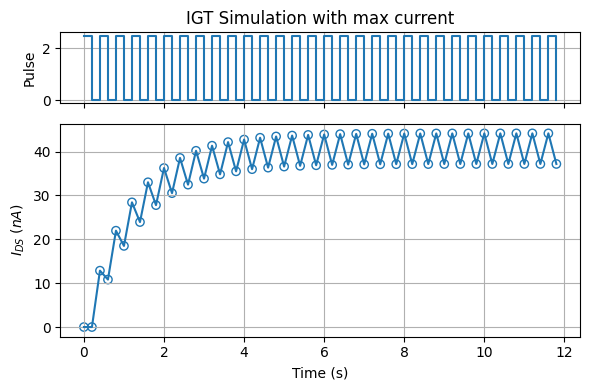

In [3]:
max_pulse = create_pulse_train(0, VOLTAGE, 1, 1, 30)

max_current = np.max(generate_single_out_current(max_pulse, K, BETA, TAU, TIME_RESOLUTION, True, "IGT Simulation with max current"))

In [4]:

zeros_flush = np.zeros((14, 1))

# Input weights
gain_input = 0.7
weight_input = rng.normal(0, 1, size=(NEURON_COUNT, 14))*gain_input

# Neurons' states
current_state = np.zeros((NEURON_COUNT, 1))

# Intern weights
weight_reservoir = rng.normal(0, 1, size=(NEURON_COUNT, NEURON_COUNT))

# Readout weights
weight_output = rng.normal(0, 1, size=(10, NEURON_COUNT))

sum_matrix = np.ones_like(current_state) @ (np.ones_like(current_state).T @ abs(weight_reservoir))
sum_matrix = (lambda x: 1/x)(sum_matrix)
normalized_reservoir = sum_matrix*weight_reservoir

target_spectral_radius = 0.7
current_radius = np.max(np.abs(np.linalg.eigvals(normalized_reservoir)))
normalized_reservoir = normalized_reservoir * (target_spectral_radius / current_radius)

In [5]:
images, labels = get_images_batch(TRAIN_BATCH_SIZE, rng=rng)
rec_images = downscale_treatment(images)

images_test, labels_test = get_images_batch(TEST_BATCH_SIZE, rng=rng, mode="TEST")
images_test = downscale_treatment(images_test).reshape((len(images_test),14,14))

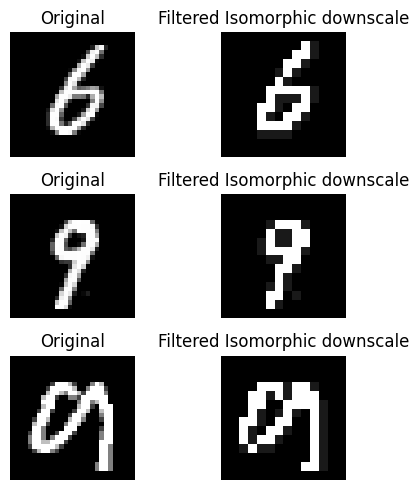

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(5, 5))

for i in range(len(images[:3])):

    # 1ª Image: Original
    axes[i][0].imshow(images[i], cmap="binary_r")
    axes[i][0].set_title("Original")
    axes[i][0].axis("off") 

    # 2ª Image: New Method
    axes[i][1].imshow(rec_images[i].reshape((14,14)), cmap="binary_r")
    axes[i][1].set_title("Filtered Isomorphic downscale")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
time_to_train = time.time()

weight_output, bias_output, current_state, scaler, pca = run_reservoir(
    rec_images, 
    labels, 
    normalized_reservoir, 
    current_state, 
    weight_input, 
    weight_output, 
    time_resolution = TIME_RESOLUTION, 
    neuron_count=NEURON_COUNT,
    max_iterations=MAX_ITERATION
    )

time_to_train = time.time() - time_to_train

C:\Users\vinicius2610042\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\vinicius2610042\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
C:\Users\vinicius2610042\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be sim

-------------------------
VARIABLES:

Beta = 0.65
Tau = 3.0
K = 400

Neuron count = 200

Train batch size = 60000
Test batch size = 10000

Image threshold = 1

Time to train = 91.84s

-------------------------
ACCURACY:

9082 / 10000 : 90.82 %


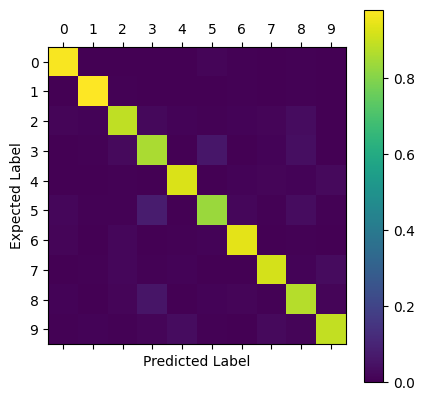

In [8]:
correct_predictions_count, confusion_matrix = run_reservoir(
    images_test, 
    labels_test, 
    normalized_reservoir, 
    current_state, 
    weight_input, 
    weight_output, 
    bias_output, 
    scaler=scaler, 
    mode="TEST", 
    pca=pca, 
    time_resolution=TIME_RESOLUTION, 
    neuron_count=NEURON_COUNT)

print(f"""-------------------------
VARIABLES:
      
Beta = {BETA}
Tau = {TAU}
K = {K}

Neuron count = {NEURON_COUNT}

Train batch size = {TRAIN_BATCH_SIZE}
Test batch size = {TEST_BATCH_SIZE}

Image threshold = {IMAGE_THRESHOLD}

Time to train = {time_to_train:.2f}s

-------------------------
ACCURACY:
""")
print(f"{correct_predictions_count} / {len(labels_test)} : {100*(correct_predictions_count/len(labels_test)):.2f} %")

plt.matshow(confusion_matrix)
plt.colorbar()
plt.xlabel("Predicted Label") 
plt.ylabel("Expected Label")
plt.xticks(np.arange(confusion_matrix.shape[0]))
plt.yticks(np.arange(confusion_matrix.shape[1]))
plt.show()